# data

In [1]:
import modules.utils as u
u.Devices()._cuda_list_gpus()

[('cuda:1', 'NVIDIA A100-SXM4-80GB', 81043),
 ('cuda:4', 'NVIDIA A100-SXM4-80GB', 81043),
 ('cuda:6', 'NVIDIA A100-SXM4-80GB', 81043),
 ('cuda:7', 'NVIDIA A100-SXM4-80GB', 81041),
 ('cuda:0', 'NVIDIA A100-SXM4-80GB', 43335),
 ('cuda:2', 'NVIDIA A100-SXM4-80GB', 39649),
 ('cuda:5', 'NVIDIA A100-SXM4-80GB', 32877),
 ('cuda:3', 'NVIDIA A100-SXM4-80GB', 391)]

In [2]:
#### mv packages ####
import modules.data as d
import modules.utils as u
from pathlib import Path

#### init ####
dataset_dir = Path('/home/mv18gs/Documents/GitHub/pathway_model/datasets/')
device, generator = u.Devices().auto_set_device(drop=['cuda:1','cuda:6'])

#### data ####
brca = d.TCGA(
    tcga_project = 'BRCA',
    tcga_dir = dataset_dir/'tcga',
    # type_col = 'sample_type',
    subtype_col = 'paper_BRCA_Subtype_PAM50',
    drop = ['Normal', 'Primary Tumor', 'Metastatic'],
    gene_name_path = dataset_dir/'other'/'name2ensg.csv',
    keep_noname = False,
)

kegg = d.KEGG(
    relation_filepath=dataset_dir/'other'/'relation_ohe.csv', 
    counts_data=brca,
)

data = d.Preprocessor(brca, kegg, kegg)
_dataset = d.GraphDataset(data)
_batch = d.get_toy_databatch(_dataset, generator)

# #### Device() ####
# device = cuda:4

# #### KEGG() ####
# relation                 (75939, 19)              DataFrame
# ensg                     4373                     list
# pathway_labels           305                      list
# edge_index               (2, 32464)               Tensor (cuda:4)
# edge_attr                (32464, 16)              Tensor (cuda:4)
# edge_labels              16                       list
# pathway_index            (4373, 305)              Tensor (cuda:4)

# #### TCGA() ####
# counts_path              PosixPath
# metadata_path            PosixPath
# gene_name_path           PosixPath
# metadata_complete        (1231, 93)               DataFrame
# metadata                 (1172, 2)                DataFrame
# y                        (1172,)                  Tensor (cuda:4)
# y_labels                 5                        list
# ensgv                    (60660, 3)               DataFrame
# ensg_complete            19213                    list
# cou

# enc+lat

In [3]:
import modules.model2 as m
from modules.model2 import Dims, Encoder, Latent
from modules.layers import AttentionSetPooling

import torch
import torch.nn as nn
from torch_geometric.nn import GCNConv, GATConv

In [4]:
# dims = Dims(
#     data=data,
#     head_dim=16,
#     num_heads=1,
#     method='set'
# )

# enc = Encoder(
#     dims=dims,
#     nb=True,
#     encoder_class=nn.Linear,
#     pooling_class=AttentionSetPooling,
#     method='set'
# )

# lat = Latent(
#     dims=dims,
#     pooling_class=AttentionSetPooling,
#     mlp=True,
#     method='set'
# )

# classifier layer

In [5]:
from modules.utils import attn_dims, cloneable, input_to_dict, reshape

from torch import Tensor
from torch_geometric.data import Data
from modules.layers import Sequential
from typing import Literal, Union

In [6]:
@cloneable
class ClassifierLayer(nn.Module):
    def __init__(
        self,
        dims:Dims,

        # layer params
        hidden_dims:list[int]=None, 
        act_fn:nn.Module=None, 
        norm_fn:Literal['batch','layer']=None, 
        end_fn:Union[bool,nn.Module]=False,  

        *args, **kwargs  
    ):
        super().__init__(*args, **kwargs)
        self.embed_dim = dims.embed_dim
        self.num_classes = dims.num_classes
        self.n_dim = dims.n_dim

        self.mlp = Sequential(
            in_channels=self.embed_dim,
            out_channels=self.num_classes,
            layer_class=nn.Linear,
            hidden_dims=hidden_dims,
            act_fn=act_fn,
            norm_fn=norm_fn,
            end_fn=end_fn
        )

    def forward(self, input:Union[Data, Tensor, dict], need_weights:bool=False):
        # input z (batch_size, embed_size)
        data = input_to_dict(input)
        x = data['x']
        y = {}
        
        # get logits
        x = self.mlp(x)
        y['y_logits'] = x # (batch_size, num_classes)

        # get probs, preds
        # if need_weights:
        y['y_probs'] = torch.softmax(x, dim=-1) # (batch_size,)
        y['y_preds'] = torch.argmax(x, dim=-1) # (batch_size,)

        return y
        
        


In [7]:
# clas = ClassifierLayer(
#     dims=dims
# )

# clas_out = clas(out, need_weights=True)

In [8]:
# clas_out.keys()

In [9]:
# clas_out['y_logits'].shape

# classifier

In [10]:
from modules.data import Preprocessor
from modules.layers import SetPooling
from modules.model2 import Dims, Encoder, Latent
from typing import Optional

In [11]:
@cloneable
class Classifier(nn.Module):
    def __init__(
        self,
        # dims
        data:Preprocessor, 
        embed_dim:int=None, 
        head_dim:int=None, 
        num_heads:int=1, 

        # nb
        nb:bool=False, # encoder (nb): decides to use nb (lfc)
        x_mean:Optional[Tensor]=None, # encoder (nb): baseline mean for nb
        learn_mu:bool=True, # encoder (nb): set mu as learnable param

        # encoder, pooling, mlp layers
        encoder_class:Union[nn.Module,Sequential]=None, # encoder: GNN class
        pooling_class:Optional[SetPooling]=None, # encoder, latent: pooling layer class
        mlp:Union[bool,Sequential]=False, # latent: use MLP after pooling

        # method
        method:Literal['set','twin']='set', # encoder, latent
        fwd:Literal['node','set','twin','twin_pool']=None, # latent

        # layer params
        hidden_dims:list[int]=None, 
        act_fn:nn.Module=None, 
        norm_fn:Literal['batch','layer']=None, 
        end_fn:Union[bool,nn.Module]=False,

        *args, **kwargs
    ):
        super().__init__(*args, **kwargs)
        self.nb = nb
        
        self.dims = Dims(
            data=data,
            embed_dim=embed_dim, head_dim=head_dim, num_heads=num_heads,
            method=method
        )

        self.encoder = Encoder(
            dims=self.dims, 
            nb=nb, x_mean=x_mean, learn_mu=learn_mu,
            encoder_class=encoder_class, pooling_class=pooling_class,
            method=method,
            hidden_dims=hidden_dims, act_fn=act_fn, norm_fn=norm_fn, end_fn=end_fn
        )

        self.latent = Latent(
            dims=self.dims,
            pooling_class=pooling_class, mlp=mlp,
            method=method, fwd=fwd,
            hidden_dims=hidden_dims, act_fn=act_fn, norm_fn=norm_fn, end_fn=end_fn
        )

        self.classifier = ClassifierLayer(
            dims=self.dims,
            hidden_dims=hidden_dims, act_fn=act_fn, norm_fn=norm_fn, end_fn=end_fn
        )

    def forward(self, input:Union[Data, Tensor, dict], need_weights:bool=False):
        x = self.encoder(input, need_weights)
        x = self.latent(x, need_weights)
        y = self.classifier(x, need_weights)

        x.update(y)

        return x
    
    def get_weights(self, input:Union[Data, Tensor, dict]):
        x = self.forward(input, need_weights=True)
        return x

In [12]:
classifier = Classifier(
    # dims
    data=data,
    head_dim=32,
    num_heads=10,
    
    # nb
    nb=True,
    # x_mean=x_mean,

    # layers
    encoder_class=GCNConv,
    pooling_class=AttentionSetPooling,
    mlp=True,
    method='set',

    # layer params
    hidden_dims=[128,128,128], 
    act_fn=nn.ReLU, 
    norm_fn='layer', 
    end_fn=False,
)

out = classifier(_batch)

print(out.keys())

dict_keys(['x', 'lfc', 'mu', 'theta', 'y_logits', 'y_probs', 'y_preds'])


---

In [13]:
from modules.train import Trainer
from modules.loss import NBLoss, UncertaintyLoss
from torchmetrics.functional.classification import multiclass_accuracy

In [14]:
class NBClassTrainer(Trainer):
    def _compute_loss(self, batch):
        # extract y
        data = input_to_dict(batch)
        y = data.get('y')

        # forward pass
        out = self.model(batch)

        # get params
        logits = out.get('y_logits')


        # compute loss
        loss = self.loss_fn(logits, y)

        if self.model.nb:
            x = data.get('x')
            mu = out.get('mu') # nb
            theta = out.get('theta')
            nb_loss = NBLoss()(x, mu, theta)
            criterion = UncertaintyLoss(num_tasks=2)

            loss = criterion([loss, nb_loss])

        return loss, out

    def _compute_metrics(self, batch_log):
        # init
        metrics = {}
        values = {}

        # compute loss
        metrics['loss'] = batch_log['loss']/batch_log['num_batches']

        # get outputs
        y = torch.cat([batch['y'] for batch in batch_log['batch']])
        # y_logits = torch.cat([batch['y_logits'] for batch in batch_log['out']])
        # y_probs = torch.cat([batch['y_probs'] for batch in batch_log['out']])
        y_preds = torch.cat([batch['y_preds'] for batch in batch_log['out']])

        # compute metrics
        # metrics['accuracy'] = multiclass_accuracy(y_preds, y, self.model.dims.num_classes, average='none')
        metrics['micro_acc'] = multiclass_accuracy(y_preds, y, self.model.dims.num_classes, average='micro')
        metrics['macro_acc'] = multiclass_accuracy(y_preds, y, self.model.dims.num_classes, average='macro')
        # metrics['weighted_acc'] = multiclass_accuracy(y_preds, y, self.model.dims.num_classes, average='weighted') # identical to micro for accuracy


        
        return metrics, values


In [15]:
import modules.train as t

In [16]:
loader = t.Loader(
    dataset=_dataset,
    generator=generator,
    batch_size=128
)

dm = t.DataloaderMean(loader.train_loader, data.num_nodes, data.num_node_features)

x_mean = dm.get_mean(4)

classifier = Classifier(
    # dims
    data=data,
    head_dim=32,
    num_heads=10,
    
    # nb
    nb=True,
    x_mean=x_mean,

    # layers
    encoder_class=nn.Linear,
    pooling_class=AttentionSetPooling,
    mlp=True,
    method='set',

    # layer params
    hidden_dims=[128,128,128], 
    act_fn=nn.ReLU, 
    norm_fn='layer', 
    end_fn=False,
)

trainer = NBClassTrainer(
    model=classifier,
    loader=loader,
    num_epochs=100,
    loss_fn=nn.CrossEntropyLoss(data.class_weights),
    optimizer_kwargs={'lr':5e-4},
    verbose=True,
    report_metrics=['loss', 'micro_acc', 'macro_acc'],
)

  0%|          | 0/100 [00:00<?, ?it/s]

100%|██████████| 100/100 [01:50<00:00,  1.11s/it, Epoch 99      Train: loss=8.7293    micro_acc=0.9732    macro_acc=0.9672        Val: loss=9.0702    micro_acc=0.8286    macro_acc=0.7111]

Test	 loss=9.2080    micro_acc=0.7714    macro_acc=0.6940



---

In [17]:
import modules.viz as v

out = v.ModelOutput(
    model=trainer.model,
    dataset=_dataset,
)

/home/mv18gs/miniconda3/envs/thesis/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [18]:
out.__dict__['values'].keys()

dict_keys(['x', 'lfc', 'mu', 'theta', 'h_ne', 'ne_out', 'h_pool', 'attn_n2s', 'h', 'z', 'z_node', 'z_set', 'attn_n2z', 'attn_s2z', 'attn_twin', 'y_logits', 'y_probs', 'y_preds', 'y'])

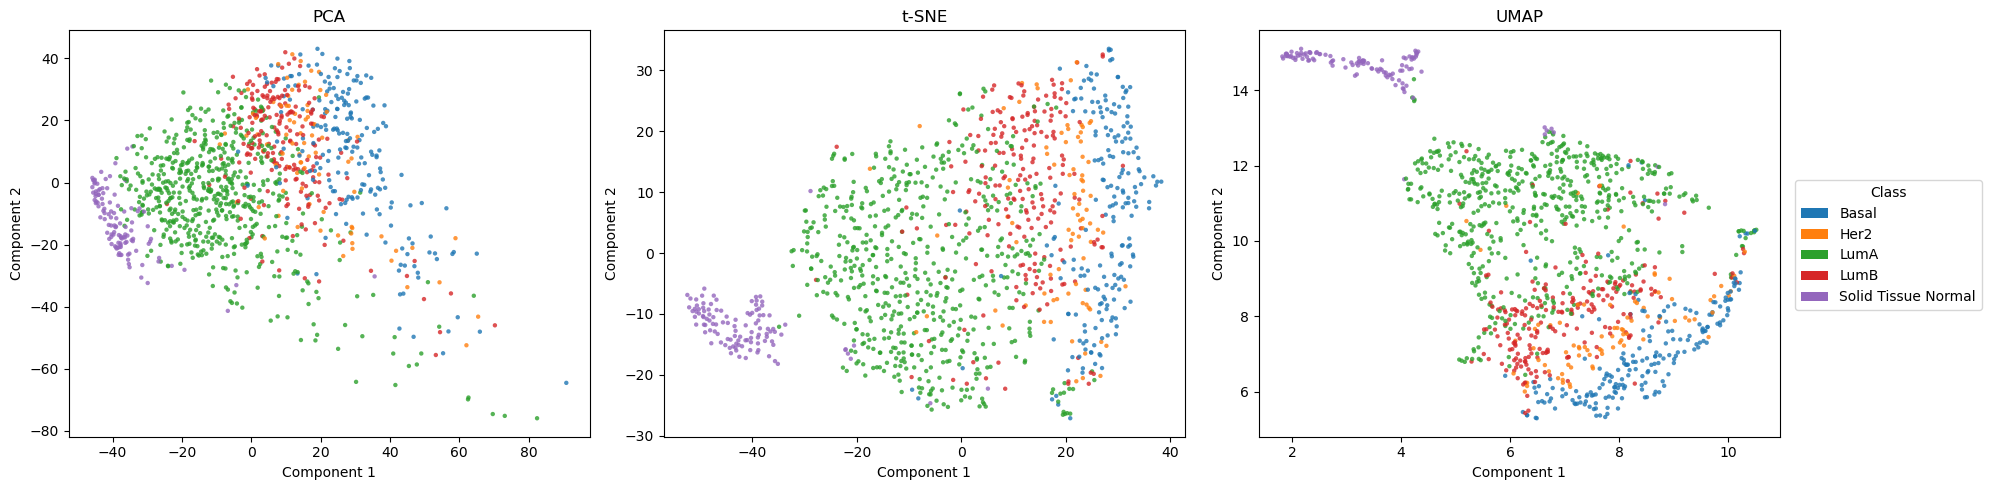

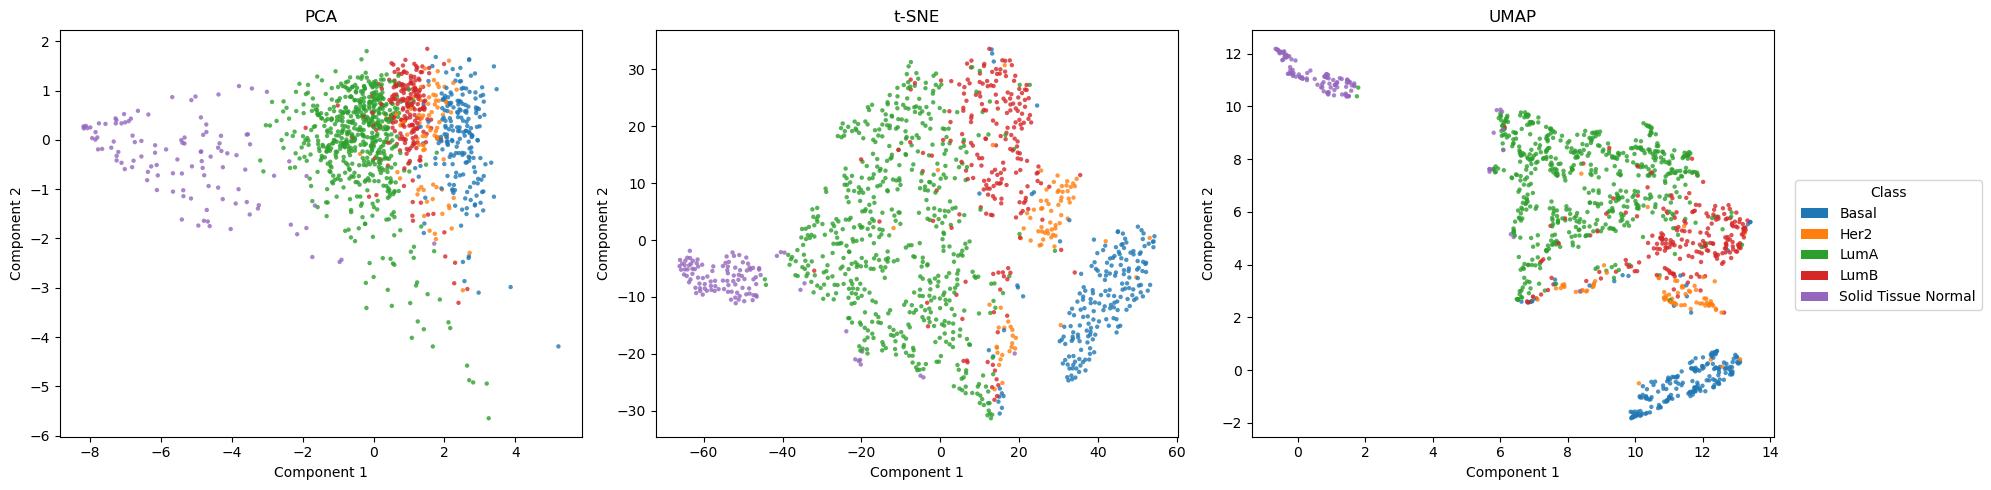

In [19]:
v.embedding_scatter(
    model_output=out,
    num_samples=data.num_samples,
    x='h',
    class_labels=data.y_labels
)

v.embedding_scatter(
    model_output=out,
    num_samples=data.num_samples,
    x='z',
    class_labels=data.y_labels
)

---

In [20]:
import seaborn as sns

<Axes: >

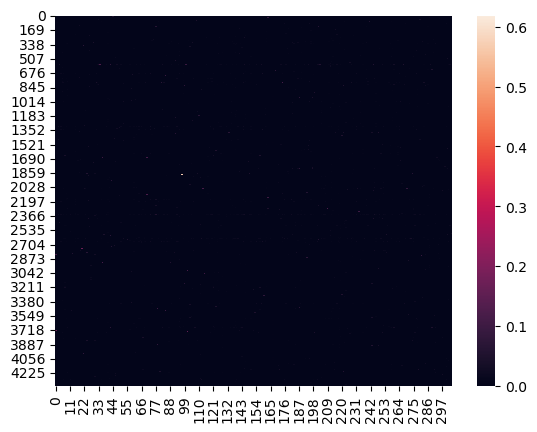

In [21]:
sns.heatmap(out.values['attn_n2s'].mean(axis=0))

<Axes: >

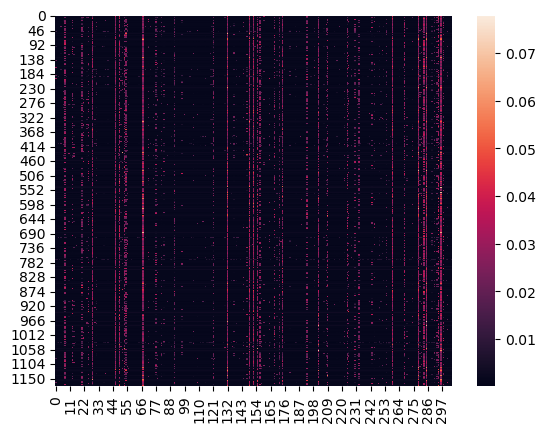

In [22]:
sns.heatmap(out.values['attn_s2z'].squeeze())

---

In [23]:
import numpy as np
import pandas as pd

In [24]:
attn = out.values['attn_s2z'].squeeze()
labels = data.y.detach().cpu().numpy()

# unique class IDs
classes = np.unique(labels)

# split per class into dictionary
class_to_attn = {c: attn[labels == c] for c in classes}

# Example: class 0's attention scores
print(class_to_attn[0].shape)  # (num_samples_in_class0, num_pathways)

(197, 305)


In [25]:
pathway_attn = pd.DataFrame(
    {
        'label':data.pathway_labels, 
        'global':attn.mean(axis=0),
        'basal':class_to_attn[0].mean(axis=0),
        'her2':class_to_attn[1].mean(axis=0),
        'lumA':class_to_attn[2].mean(axis=0),
        'lumB':class_to_attn[3].mean(axis=0),
        'norm':class_to_attn[4].mean(axis=0),
    }
)

pathway_attn = pathway_attn.sort_values(by='global', ascending=False)

pathway_attn

,label,global,basal,her2,lumA,lumB,norm
279,path:hsa00982,0.028560,0.020652,0.022661,0.033033,0.025434,0.029806
132,path:hsa00360,0.027967,0.020270,0.021985,0.032120,0.024689,0.030801
285,path:hsa00350,0.027879,0.020219,0.021471,0.031459,0.024430,0.034178
296,path:hsa04260,0.027479,0.021204,0.022943,0.030037,0.024368,0.034543
67,path:hsa00980,0.026684,0.019595,0.021678,0.030208,0.024396,0.029106
...,...,...,...,...,...,...,...
266,path:hsa00310,0.001404,0.000943,0.001053,0.001461,0.001175,0.002596
302,path:hsa04928,0.001404,0.000943,0.001054,0.001460,0.001176,0.002595
110,path:hsa00770,0.001403,0.000941,0.001052,0.001460,0.001175,0.002595
276,path:hsa05017,0.001403,0.000941,0.001051,0.001460,0.001175,0.002595


<Axes: ylabel='label'>

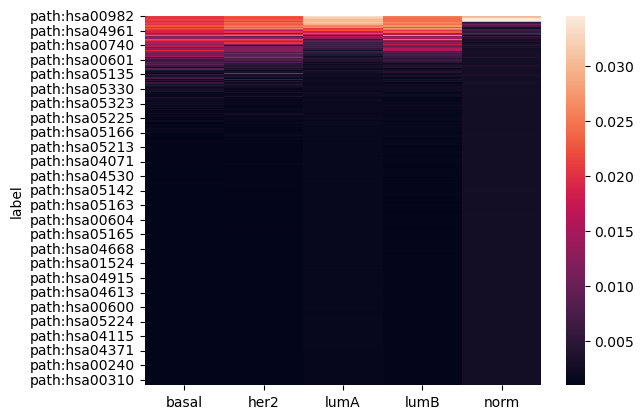

In [40]:
sns.heatmap(pathway_attn.drop(columns=['global']).set_index('label'))

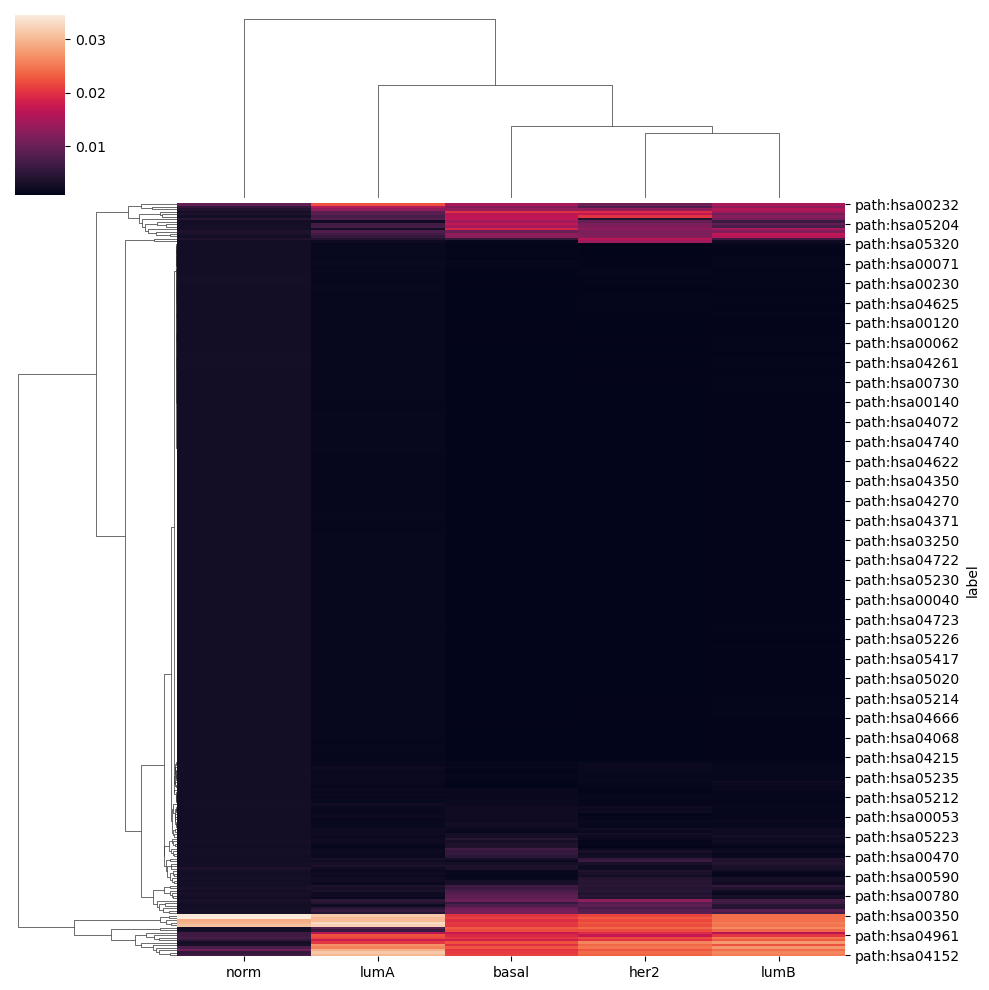

In [26]:
sns.clustermap(pathway_attn.drop(columns=['global']).set_index('label'))

<Axes: xlabel='global', ylabel='Density'>

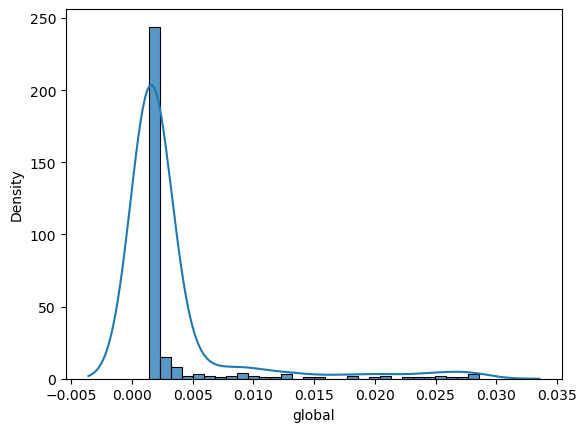

In [27]:
sns.kdeplot(pathway_attn['global'])
sns.histplot(pathway_attn['global'], bins=30)

---

In [28]:
attn = out.values['attn_s2z'].squeeze()
labels = data.y.detach().cpu().numpy()

# unique class IDs
classes = np.unique(labels)

# split per class into dictionary
class_to_attn = {c: attn[labels == c] for c in classes}

# Example: class 0's attention scores
print(class_to_attn[0].shape)  # (num_samples_in_class0, num_pathways)


(197, 305)


In [29]:
n2s = out.values['attn_n2s']

labels = data.y.detach().cpu().numpy()
classes = np.unique(labels)

class_n2s = {c: n2s[labels == c] for c in classes}

<Axes: >

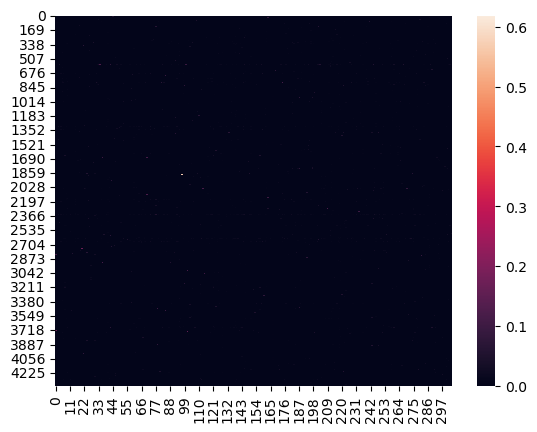

In [30]:
sns.heatmap(n2s.mean(axis=0))

In [31]:
node_attn = pd.DataFrame({
    'labels':data.x_labels,
    'global':n2s.mean(0).mean(-1),
    'basal':class_n2s[0].mean(0).mean(-1),
    'her2':class_n2s[1].mean(0).mean(-1),
    'lumA':class_n2s[2].mean(0).mean(-1),
    'lumB':class_n2s[3].mean(0).mean(-1),
    'norm':class_n2s[4].mean(0).mean(-1),
})

# node_attn = pd.DataFrame({
#     'labels':data.x_labels,
#     'global':n2s.mean(0).sum(-1),
#     'basal':class_n2s[0].mean(0).sum(-1),
#     'her2':class_n2s[1].mean(0).sum(-1),
#     'lumA':class_n2s[2].mean(0).sum(-1),
#     'lumB':class_n2s[3].mean(0).sum(-1),
#     'norm':class_n2s[4].mean(0).sum(-1),
# })

node_attn = node_attn.sort_values(by='global', ascending=False)

node_attn

,labels,global,basal,her2,lumA,lumB,norm
835,MAPK3,0.004834,0.004734,0.004820,0.004854,0.004879,0.004834
686,MAPK1,0.004790,0.004776,0.004807,0.004781,0.004818,0.004790
760,CD40,0.004758,0.004779,0.004711,0.004717,0.004922,0.004656
2213,AKT1,0.004741,0.004682,0.004830,0.004767,0.004717,0.004694
918,AKT2,0.004681,0.004645,0.004656,0.004689,0.004708,0.004674
...,...,...,...,...,...,...,...
4210,ZNF727,0.000005,0.000006,0.000005,0.000004,0.000004,0.000009
4022,ZNF677,0.000005,0.000006,0.000004,0.000004,0.000003,0.000010
2759,ZNF208,0.000004,0.000004,0.000004,0.000004,0.000004,0.000008
3874,ZNF676,0.000004,0.000003,0.000003,0.000003,0.000003,0.000009


In [41]:
node_attn.head(30)

,labels,global,basal,her2,lumA,lumB,norm
835,MAPK3,0.004834,0.004734,0.004820,0.004854,0.004879,0.004834
686,MAPK1,0.004790,0.004776,0.004807,0.004781,0.004818,0.004790
760,CD40,0.004758,0.004779,0.004711,0.004717,0.004922,0.004656
2213,AKT1,0.004741,0.004682,0.004830,0.004767,0.004717,0.004694
918,AKT2,0.004681,0.004645,0.004656,0.004689,0.004708,0.004674
1361,AKT3,0.004305,0.004318,0.004172,0.004311,0.004164,0.004611
378,PRKACA,0.004296,0.004402,0.004427,0.004271,0.004434,0.003887
1380,PIK3R3,0.004269,0.004208,0.004395,0.004301,0.004250,0.004157
220,PIK3CB,0.004178,0.004143,0.004206,0.004182,0.004170,0.004213
3284,PIK3CD,0.004114,0.004218,0.004065,0.004101,0.004021,0.004206


<Axes: xlabel='global', ylabel='Density'>

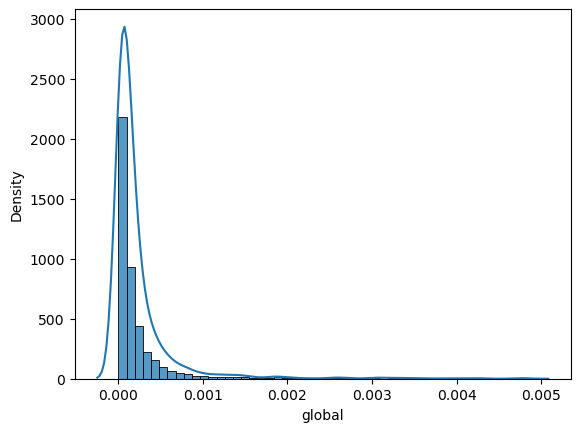

In [33]:
sns.kdeplot(node_attn['global'])
sns.histplot(node_attn['global'], bins=50)

<Axes: ylabel='labels'>

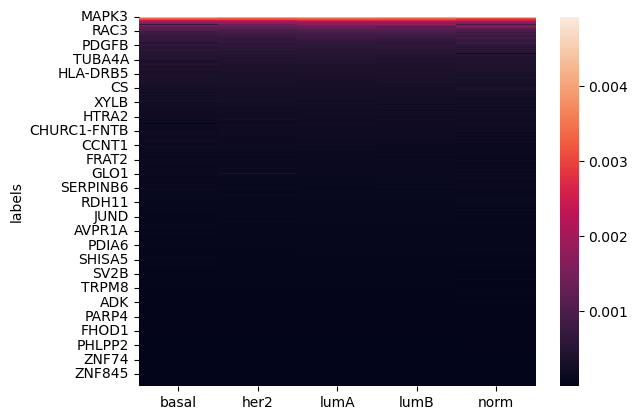

In [39]:
sns.heatmap(node_attn.drop(columns=['global']).set_index('labels'))

/home/mv18gs/miniconda3/envs/thesis/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/mv18gs/miniconda3/envs/thesis/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


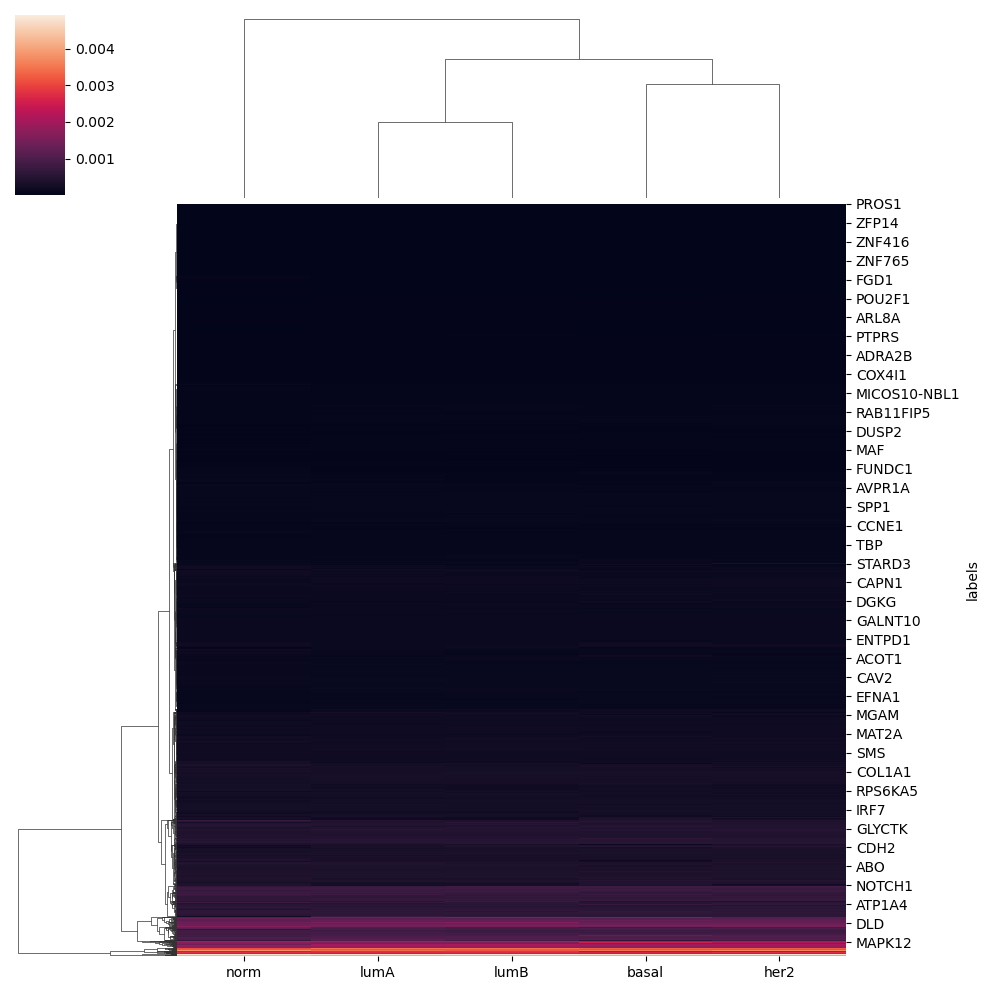

In [38]:
sns.clustermap(node_attn.drop(columns=['global']).set_index('labels'))